## PHÂN LOẠI MNIST BẰNG CNN

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [2]:
# Chuẩn hoá MNIST với mean/std của tập train.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f'Số ảnh train: {len(train_dataset)},  test: {len(test_dataset)}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 54.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.78MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.64MB/s]

Số ảnh train: 60000,  test: 10000


In [3]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)   # 28→26
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # 13→11
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # → (16, 13, 13)
        x = self.pool(torch.relu(self.conv2(x)))   # → (32,  5,  5)
        x = x.view(x.size(0), -1)                  # flatten
        x = self.fc1(x)                            # logits
        return x

model = MNIST_CNN().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'Tổng tham số: {n_params:,}')

MNIST_CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=800, out_features=10, bias=True)
)
Tổng tham số: 12,810


In [6]:
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5
loss_history, acc_history = [], []
test_loss_history, test_acc_history = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model, test_loader)
    loss_history.append(train_loss); acc_history.append(train_acc)
    test_loss_history.append(test_loss); test_acc_history.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  '
          f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')

Epoch 1/5  train_loss=0.1967  train_acc=94.29%  test_loss=0.0733  test_acc=97.59%
Epoch 2/5  train_loss=0.0633  train_acc=98.07%  test_loss=0.0511  test_acc=98.24%
Epoch 3/5  train_loss=0.0463  train_acc=98.58%  test_loss=0.0364  test_acc=98.93%
Epoch 4/5  train_loss=0.0387  train_acc=98.81%  test_loss=0.0346  test_acc=98.84%
Epoch 5/5  train_loss=0.0319  train_acc=98.99%  test_loss=0.0344  test_acc=98.81%


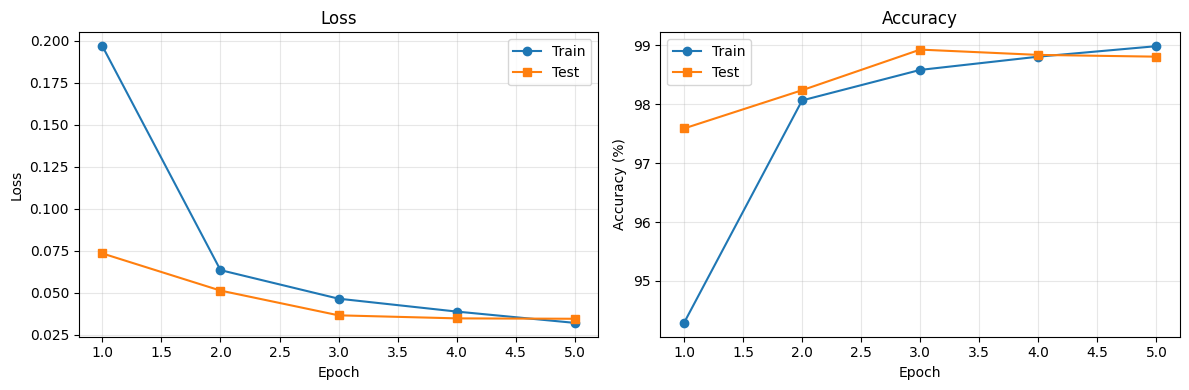

In [7]:
epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, loss_history,      'o-', label='Train')
axes[0].plot(epochs, test_loss_history, 's-', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Loss')
axes[1].plot(epochs, [a*100 for a in acc_history],      'o-', label='Train')
axes[1].plot(epochs, [a*100 for a in test_acc_history], 's-', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Accuracy')
plt.tight_layout(); plt.show()

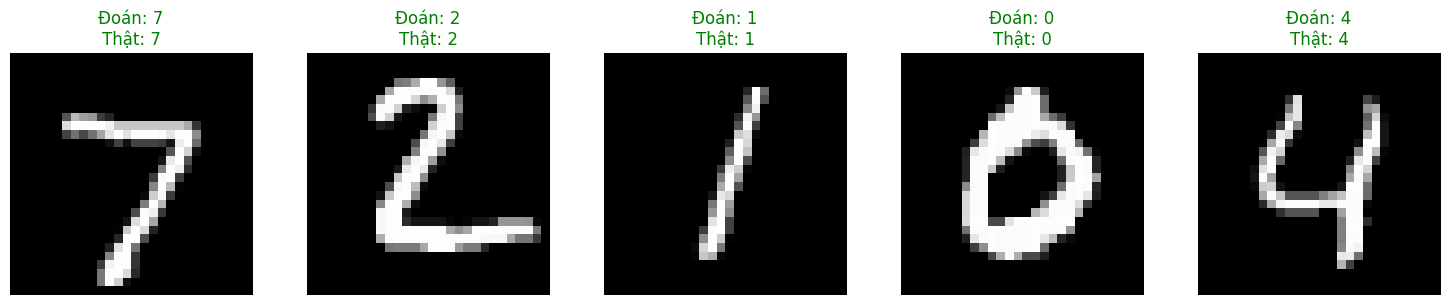

In [8]:

model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
    preds = model(images).argmax(1)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = images[i].cpu().squeeze() * 0.3081 + 0.1307   # un-normalize để nhìn cho đẹp
    axes[i].imshow(img, cmap='gray')
    color = 'green' if preds[i] == labels[i] else 'red'
    axes[i].set_title(f'Đoán: {preds[i].item()}\nThật: {labels[i].item()}', color=color)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

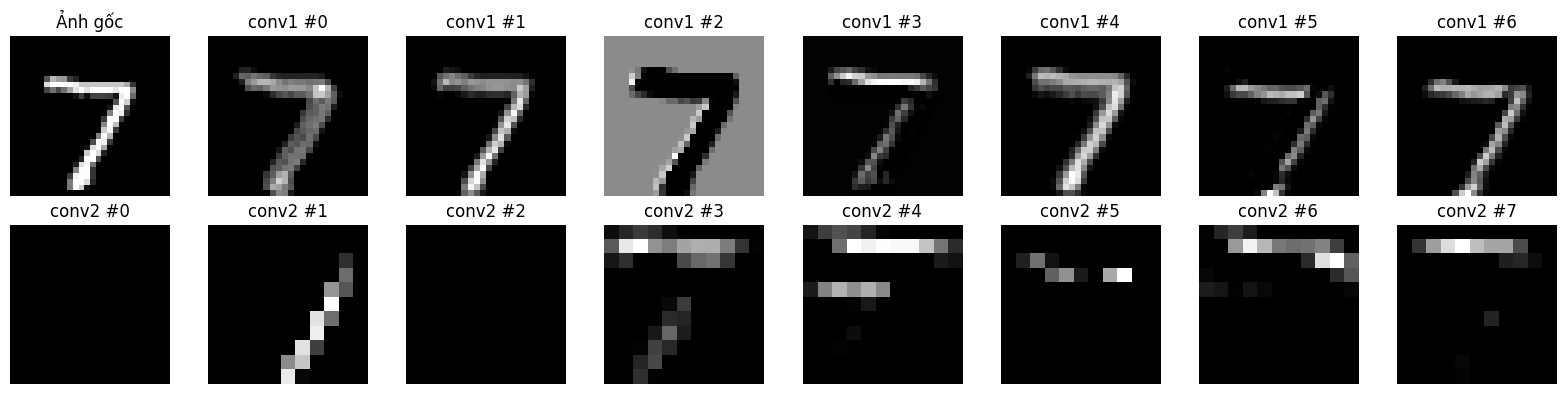

Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.
         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)


In [9]:

model.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    fmap1 = torch.relu(model.conv1(img))           # (1, 16, 26, 26)
    fmap2 = torch.relu(model.conv2(model.pool(fmap1)))  # (1, 32, 11, 11)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
axes[0, 0].imshow(img.cpu().squeeze() * 0.3081 + 0.1307, cmap='gray')
axes[0, 0].set_title('Ảnh gốc'); axes[0, 0].axis('off')
for i in range(7):
    axes[0, i+1].imshow(fmap1[0, i].cpu(), cmap='gray')
    axes[0, i+1].set_title(f'conv1 #{i}'); axes[0, i+1].axis('off')
for i in range(8):
    axes[1, i].imshow(fmap2[0, i].cpu(), cmap='gray')
    axes[1, i].set_title(f'conv2 #{i}'); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

print('Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.')
print('         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)')

## CÂU 1

In [10]:
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
loss_history, acc_history = [], []
test_loss_history, test_acc_history = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model, test_loader)
    loss_history.append(train_loss); acc_history.append(train_acc)
    test_loss_history.append(test_loss); test_acc_history.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  '
          f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')

Epoch 1/10  train_loss=0.0285  train_acc=99.12%  test_loss=0.0395  test_acc=98.73%
Epoch 2/10  train_loss=0.0248  train_acc=99.18%  test_loss=0.0349  test_acc=98.89%
Epoch 3/10  train_loss=0.0194  train_acc=99.36%  test_loss=0.0381  test_acc=98.86%
Epoch 4/10  train_loss=0.0174  train_acc=99.40%  test_loss=0.0353  test_acc=98.89%
Epoch 5/10  train_loss=0.0151  train_acc=99.53%  test_loss=0.0408  test_acc=98.76%
Epoch 6/10  train_loss=0.0143  train_acc=99.55%  test_loss=0.0428  test_acc=98.75%
Epoch 7/10  train_loss=0.0109  train_acc=99.64%  test_loss=0.0457  test_acc=98.64%
Epoch 8/10  train_loss=0.0104  train_acc=99.66%  test_loss=0.0375  test_acc=98.95%
Epoch 9/10  train_loss=0.0092  train_acc=99.70%  test_loss=0.0428  test_acc=98.83%
Epoch 10/10  train_loss=0.0086  train_acc=99.70%  test_loss=0.0485  test_acc=98.69%


Khoảng cách train_acc và test_acc: Khi số epoch tăng dần, train_acc có xu hướng tiến rất sát 100%, trong khi test_acc không tăng tương xứng. Khoảng cách (train_acc - test_acc) sẽ mở rộng dần.

Dấu hiệu: Đây chính là dấu hiệu của hiện tượng overfitting (quá khớp), mô hình bắt đầu học thuộc lòng các chi tiết nhiễu của tập dữ liệu huấn luyện thay vì tổng quát hóa trên dữ liệu mới.

## CÂU 2

In [12]:
class MNIST_CNN_Q2(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0) # 28→26
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0) # 13→11
        # Thêm conv3 padding=1 để không làm giảm thêm kích thước feature map
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)

        # Sau conv2 + pool (32, 5, 5). Sau conv3 + pool (64, 2, 2)
        self.fc1   = nn.Linear(64 * 2 * 2, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x))) # → (16, 13, 13)
        x = self.pool(torch.relu(self.conv2(x))) # → (32,  5,  5)
        x = self.pool(torch.relu(self.conv3(x))) # → (64, 2, 2)

        x = x.view(x.size(0), -1) # flatten
        x = self.fc1(x) # logits
        return x

# Khởi tạo model mới và in thử số lượng tham số
model_q2 = MNIST_CNN_Q2().to(device)
print(model_q2)

MNIST_CNN_Q2(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=256, out_features=10, bias=True)
)


Bằng cách thêm tầng conv3 với số lượng filter lớn hơn (64), ta giúp mạng trích xuất được các đặc trưng phức tạp và sâu hơn. Padding=1 được sử dụng để giữ nguyên kích thước (5x5) trước khi qua pooling layer tiếp theo, để tránh việc feature map bị thu quá nhỏ (dẫn đến mất mát thông tin hoặc lỗi shape).

## CÂU 3

--- Đang train với lr = 0.001 ---
--- Đang train với lr = 0.01 ---
--- Đang train với lr = 0.1 ---


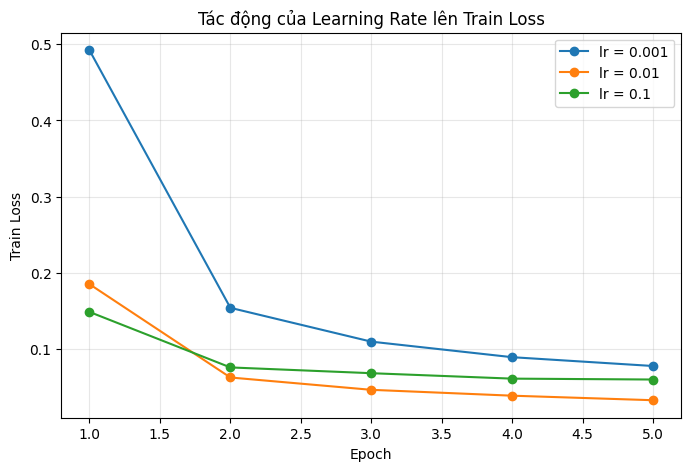

In [13]:
lrs = [0.001, 0.01, 0.1]
losses_dict = {}

for lr in lrs:
    print(f"--- Đang train với lr = {lr} ---")
    model_q3 = MNIST_CNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model_q3.parameters(), lr=lr, momentum=0.9)

    loss_history_q3 = []
    for epoch in range(5):
        model_q3.train()
        running_loss, total = 0.0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model_q3(images), labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            total += labels.size(0)
        loss_history_q3.append(running_loss / total)
    losses_dict[lr] = loss_history_q3

# Vẽ đồ thị
epochs = range(1, 6)
plt.figure(figsize=(8, 5))
for lr, hist in losses_dict.items():
    plt.plot(epochs, hist, marker='o', label=f'lr = {lr}')
plt.xlabel('Epoch'); plt.ylabel('Train Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Tác động của Learning Rate lên Train Loss')
plt.show()

lr = 0.001 (quá thấp): Đồ thị loss giảm rất chậm chạp. Bước cập nhật trọng số nhỏ khiến quá trình học mất rất nhiều epoch để hội tụ.

lr = 0.01 (hợp lý): Loss giảm nhanh, ổn định và mượt mà, đạt mức tối ưu hiệu quả nhất.

lr = 0.1 (quá cao): Loss có thể giảm rất nhanh ban đầu nhưng đồ thị thường dễ bị khựng lại, dao động mạnh hoặc bị bùng nổ (tăng vọt) ở các epoch sau do bước nhảy gradient lớn khiến mô hình trượt qua khỏi điểm cực tiểu toàn cục.

Kết luận: Learning rate quyết định độ lớn của mỗi bước điều chỉnh trọng số (weights). Chọn LR đúng là yếu tố cực kỳ quan trọng để model hội tụ ổn định.

## CÂU 4

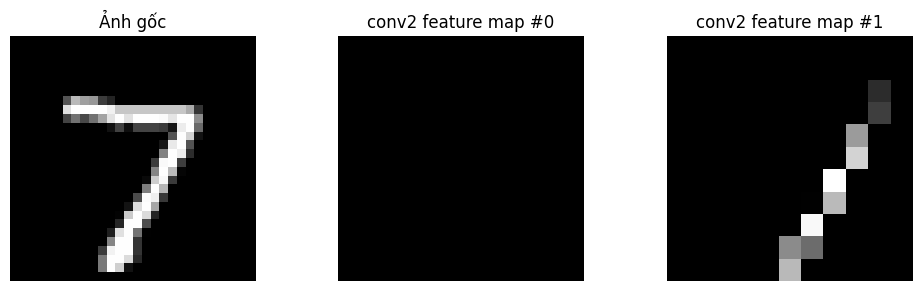

In [14]:
model.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    h1 = torch.relu(model.conv1(img))
    h1 = model.pool(h1)
    # Feature map của conv2 (1, 32, 11, 11)
    h2 = torch.relu(model.conv2(h1))

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(img.cpu().squeeze() * 0.3081 + 0.1307, cmap='gray')
axes[0].set_title('Ảnh gốc'); axes[0].axis('off')

# Lấy 2 kênh đầu tiên từ feature map của conv2
for i in range(2):
    axes[i+1].imshow(h2[0, i].cpu(), cmap='gray')
    axes[i+1].set_title(f'conv2 feature map #{i}')
    axes[i+1].axis('off')

plt.tight_layout(); plt.show()

Feature map của Conv1: Rất cụ thể. Chúng ta vẫn nhìn rõ hình dáng của con số (các nét ngang, nét dọc, viền ngoài), filter chỉ đang tìm kiếm các nét cơ bản.

Feature map của Conv2: Trừu tượng hơn rất nhiều và kích thước không gian đã bị thu nhỏ. Nhìn bằng mắt thường, nó không còn rõ hình dáng con số, vì nó tổng hợp lại những cạnh/góc từ tầng 1 để tạo thành các đặc trưng bậc cao hơn (ví dụ: "đây có phải một vòng tròn khép kín ở nửa trên không").

## CÂU 5

Bắt đầu huấn luyện mô hình bổ sung Dropout và Data Augmentation...
Epoch 01/10 | Train Loss: 0.4214 - Train Acc: 86.48% | Test Loss: 0.0605 - Test Acc: 98.10%
Epoch 02/10 | Train Loss: 0.1779 - Train Acc: 94.42% | Test Loss: 0.0410 - Test Acc: 98.82%
Epoch 03/10 | Train Loss: 0.1434 - Train Acc: 95.62% | Test Loss: 0.0367 - Test Acc: 98.82%
Epoch 04/10 | Train Loss: 0.1285 - Train Acc: 95.92% | Test Loss: 0.0274 - Test Acc: 99.12%
Epoch 05/10 | Train Loss: 0.1161 - Train Acc: 96.45% | Test Loss: 0.0287 - Test Acc: 99.15%
Epoch 06/10 | Train Loss: 0.1105 - Train Acc: 96.56% | Test Loss: 0.0246 - Test Acc: 99.24%
Epoch 07/10 | Train Loss: 0.1037 - Train Acc: 96.83% | Test Loss: 0.0285 - Test Acc: 99.14%
Epoch 08/10 | Train Loss: 0.1038 - Train Acc: 96.81% | Test Loss: 0.0267 - Test Acc: 99.18%
Epoch 09/10 | Train Loss: 0.0984 - Train Acc: 96.96% | Test Loss: 0.0257 - Test Acc: 99.19%
Epoch 10/10 | Train Loss: 0.0920 - Train Acc: 97.11% | Test Loss: 0.0287 - Test Acc: 99.13%


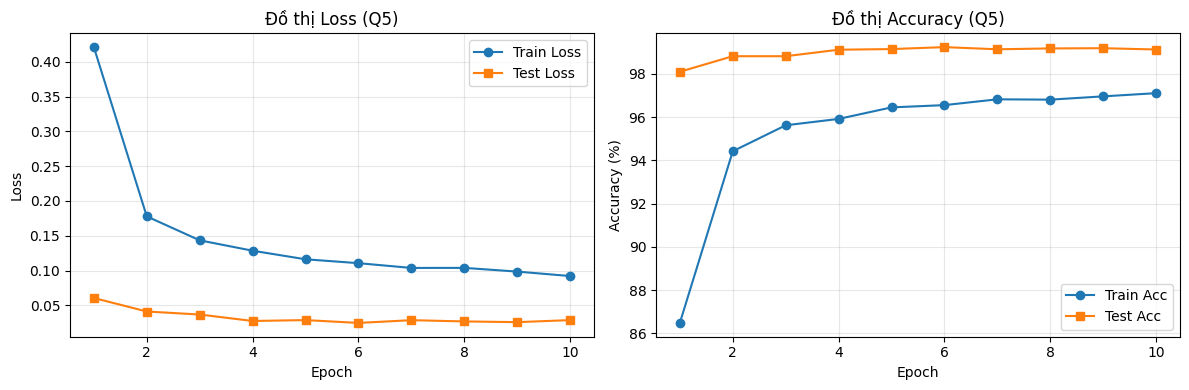

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Định nghĩa thiết bị chạy (nếu chưa chạy các cell trên)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Thêm Augmentation vào cấu hình biến đổi của tập Train
train_transform_aug = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)), # Xoay và dịch ảnh nhẹ
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Tập Test giữ nguyên không áp dụng Augmentation
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Khởi tạo lại Data Loader với ảnh đã được biến đổi (Augmented)
train_dataset_aug = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=train_transform_aug)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=test_transform)

train_loader_aug = torch.utils.data.DataLoader(train_dataset_aug, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

# 2. Định nghĩa kiến trúc mạng mạng CNN có thêm Dropout
class MNIST_CNN_Aug(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)

        # Thêm lớp Dropout với tỷ lệ loại bỏ 25% trước khi vào lớp Fully Connected
        self.dropout = nn.Dropout(p=0.25)
        self.fc1   = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1) # Flatten

        x = self.dropout(x)       # Áp dụng Dropout khi huấn luyện
        x = self.fc1(x)           # Tính toán Logits
        return x

# Khởi tạo mô hình, hàm mất mát và thuật toán tối ưu
model_q5 = MNIST_CNN_Aug().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_q5.parameters(), lr=0.01, momentum=0.9)

# 3. Vòng lặp huấn luyện chính thức trong 10 Epochs
num_epochs_q5 = 10
loss_history_q5, acc_history_q5 = [], []
test_loss_history_q5, test_acc_history_q5 = [], []

print("Bắt đầu huấn luyện mô hình bổ sung Dropout và Data Augmentation...")

for epoch in range(num_epochs_q5):
    model_q5.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader_aug:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_q5(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total

    # Đánh giá trên tập test (Hàm evaluate đã được định nghĩa ở phần trên của Lab)
    test_loss, test_acc = evaluate(model_q5, test_loader)

    loss_history_q5.append(train_loss)
    acc_history_q5.append(train_acc)
    test_loss_history_q5.append(test_loss)
    test_acc_history_q5.append(test_acc)

    print(f'Epoch {epoch+1:02d}/{num_epochs_q5} | '
          f'Train Loss: {train_loss:.4f} - Train Acc: {train_acc*100:.2f}% | '
          f'Test Loss: {test_loss:.4f} - Test Acc: {test_acc*100:.2f}%')

# 4. Trực quan hóa kết quả học tập bằng đồ thị
epochs = range(1, num_epochs_q5 + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, loss_history_q5, 'o-', label='Train Loss')
axes[0].plot(epochs, test_loss_history_q5, 's-', label='Test Loss')
axes[0].set_title('Đồ thị Loss (Q5)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, [a*100 for a in acc_history_q5], 'o-', label='Train Acc')
axes[1].plot(epochs, [a*100 for a in test_acc_history_q5], 's-', label='Test Acc')
axes[1].set_title('Đồ thị Accuracy (Q5)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

So sánh kết quả thực nghiệm: So với mô hình gốc ở Câu 1 khi train 10 epoch mà không có kỹ thuật bổ trợ, mô hình Câu 5 có train_acc tăng chậm hơn (không dễ dàng chạm mốc 100% ngay từ các epoch giữa). Tuy nhiên, test_acc lại duy trì ở mức rất cao và ổn định, khoảng cách giữa đường Train và Test thu hẹp lại đáng kể.

Cơ chế giảm Overfitting của Data Augmentation: Bằng cách xoay và dịch chuyển ngẫu nhiên, ta tạo ra các biến thể ảnh mới liên tục. Việc này làm giàu tập dữ liệu, ngăn mạng nơ-ron "học thuộc lòng" chính xác từng vị trí pixel cố định của ảnh gốc mà phải học cấu trúc thực tế của chữ số.

Cơ chế giảm Overfitting của Dropout: Việc ngẫu nhiên tắt đi 25% nơ-ron ở mỗi bước forward ép mô hình không được phụ thuộc vào bất kỳ một cụm tính chất hay nơ-ron cụ thể nào. Các nơ-ron buộc phải phối hợp đồng đều và tự học các đặc trưng mang tính tổng quát tốt hơn.

Kết luận: Sự kết hợp của cả hai kỹ thuật giúp cải thiện khả năng tổng quát hóa (generalization) của mô hình CNN một cách triệt để trên dữ liệu thực tế.